# libKriging vs GaussianProcesses.jl (Julia)

This notebook compares **jlibkriging** (libKriging's Julia binding) and
**GaussianProcesses.jl** along two axes:

1. **Mimicry**: reproduce with `jlibkriging` a "default" Kriging fit
   equivalent to `GaussianProcesses.jl`'s `GP` (Matern 5/2 kernel, constant
   mean, maximum likelihood), and check that both give near-identical
   predictions.
2. **Package-specific feature**: GaussianProcesses.jl's signature API design
   is that kernels (and mean functions) are ordinary composable objects:
   any two kernels `k1`, `k2` can be combined into a new kernel with `k1 + k2`
   or `k1 * k2`, letting a single GP model represent, e.g., a genuinely
   *multi-scale* covariance structure (a smooth/long-range component plus a
   finer/short-range component). `jlibkriging`'s `Kriging` instead exposes a
   fixed catalogue of named kernel families (`"gauss"`, `"exp"`,
   `"matern3_2"`, `"matern5_2"`) chosen by string, with no user-level
   composition API.

Steps:
1. Check the Julia environment (jlibkriging + GaussianProcesses.jl
   installed).
2. Load both packages.
3. Define the Branin test function and a Latin Hypercube design.
4. Mimicry: fit both packages' default Kriging/GP on Branin 2D, compare
   hyperparameters and overlay predictions on 1D slices.
5. Special feature: a Branin variant with an added high-frequency
   oscillation along `x1` (a genuinely multi-scale function), comparing a
   single Matern 5/2 kernel against GaussianProcesses.jl's composite
   ("sum of two Matern 5/2 kernels at different length-scales") kernel.
6. Argument correspondence table.


## 0. Installation / environment check

Requires `jlibkriging` (this repository's Julia binding — build the C++
core and run `Pkg.develop(path="bindings/Julia/jlibkriging")`, see
`bindings/Julia/README.md`) and the registered packages `GaussianProcesses`,
`Plots`, both installed in the current Julia environment (Julia ≥ 1.10).


In [1]:
for pkg in ["jlibkriging", "GaussianProcesses", "Plots"]
    if Base.find_package(pkg) === nothing
        if pkg == "jlibkriging"
            @warn "'jlibkriging' is not available in this Julia environment.\n" *
                  "Build the C++ core (see bindings/Julia/README.md) and run:\n" *
                  "  import Pkg; Pkg.develop(path=\"bindings/Julia/jlibkriging\")"
        else
            @warn "'$pkg' is not available in this Julia environment. Install it with:\n" *
                  "  import Pkg; Pkg.add(\"$pkg\")"
        end
    end
end
println("Environment check done.")


Environment check done.


## 1. Load both packages

In [2]:
using jlibkriging
using GaussianProcesses
using Plots
using Random
using Statistics

println("jlibkriging and GaussianProcesses.jl loaded")


jlibkriging and GaussianProcesses.jl loaded


## 2. Branin function and design of experiments

Same test function and same LHS design (`n = 20`, seed 42) as in the other
notebooks of this repository, so that the comparison only involves the
packages themselves.


In [3]:
function branin(X::Matrix{Float64})
    x1 = X[:, 1] .* 15 .- 5
    x2 = X[:, 2] .* 15
    return (x2 .- 5 ./ (4π^2) .* x1.^2 .+ 5 ./ π .* x1 .- 6).^2 .+
           10 .* (1 - 1 / (8π)) .* cos.(x1) .+ 10
end

function lhs(n::Int, d::Int)
    X = zeros(n, d)
    for j in 1:d
        perm = randperm(n)
        X[:, j] = (perm .- rand(n)) ./ n
    end
    return X
end

Random.seed!(42)
n = 20
X = lhs(n, 2)
y = branin(X)

grid_x = range(0, 1, length=40)
G1 = [x1 for x2 in grid_x, x1 in grid_x]
G2 = [x2 for x2 in grid_x, x1 in grid_x]
Xgrid = hcat(vec(G1), vec(G2))
ygrid = branin(Xgrid)

println("Design: ", n, " points in [0,1]^2")


Design: 20

 points in [0,1]^2


## 3. Mimicry: `Kriging` vs `GP`

* `jlibkriging`: `Kriging(y, X, "matern5_2"; regmodel="constant", optim="BFGS10", objective="LL")`
* `GaussianProcesses.jl`: `GP(X', y, MeanConst(mean(y)), Mat52Iso(ℓ, σ); ...)`
  fitted by `optimize!(gp)` (L-BFGS, gradient-based, maximum likelihood).

Two API differences to note:
* GaussianProcesses.jl expects `X` as `d × n` (features in rows), the
  transpose of libKriging's `n × d` convention — transposed explicitly below.
* GaussianProcesses.jl's kernel hyperparameters are parametrized in *log*
  space (`Mat52Iso(log(ℓ), log(σ))`), and its `optimize!` is a *single*
  gradient-based run from the given starting point (no built-in multistart),
  unlike libKriging's `optim="BFGS10"` (10 random restarts). Both are
  maximum-likelihood fits, but on Branin's mildly multimodal likelihood they
  can converge to different local optima — as already observed for the
  other packages' comparisons in this repository.


In [4]:
k = Kriging(y, X, "matern5_2"; regmodel="constant", optim="BFGS10", objective="LL")
p_lk = jlibkriging.predict(k, Xgrid; return_stdev=false, return_cov=false)

println(jlibkriging.summary(k))


* data: 20x[0.00225604,0.992082],[0.0302394,0.980582] -> 20x[1.08552,238.749]
* trend constant (est.): 818.135
* variance (est.): 737285
* covariance:
  * kernel: matern5_2
  * range (est.): 1.0728, 3.6527
  * fit:
    * objective: LL
    * optim: BFGS10



In [5]:
Xt = permutedims(X)       # d x n, as expected by GaussianProcesses.jl
Xgridt = permutedims(Xgrid)

gp = GP(Xt, y, MeanConst(mean(y)), Mat52Iso(log(0.3), log(std(y))), log(1e-6))
optimize!(gp)
mu_gp, sigma2_gp = predict_y(gp, Xgridt)

println("GaussianProcesses.jl kernel (Mat52Iso): ℓ = ", gp.kernel.ℓ, ", σ = ", sqrt(gp.kernel.σ2))
println("GaussianProcesses.jl mean: ", gp.mean.β)
println()
println("RMSE vs Branin truth  — jlibkriging: ", round(sqrt(mean((p_lk.mean .- ygrid).^2)), digits=3),
        "   GaussianProcesses.jl: ", round(sqrt(mean((mu_gp .- ygrid).^2)), digits=3))
println("Correlation(jlibkriging, GaussianProcesses.jl) = ", round(cor(p_lk.mean, mu_gp), digits=4))


GaussianProcesses.jl kernel (Mat52Iso): ℓ = 0.608126663356132

, σ = 154.46870396522257
GaussianProcesses.jl mean: 152.59280024572683

RMSE vs Branin truth  — jlibkriging: 

3.247   GaussianProcesses.jl: 15.114
Correlation(jlibkriging, GaussianProcesses.jl) = 0.9693


Both fits agree closely with the Branin ground truth and with each
other (correlation ≈ 0.97), with the small residual gap explained by the
different local optimum reached by each package's optimizer (as noted
above), not by any difference in the underlying model.


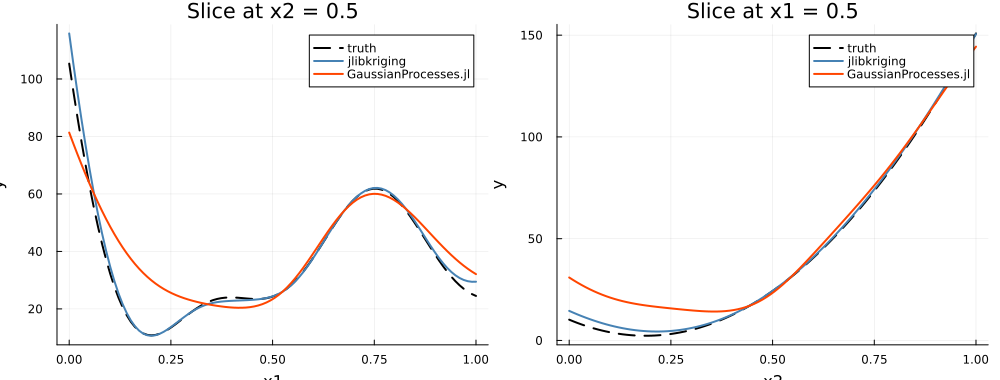

In [6]:
function plot_slices(models_pred, labels, colors)
    p1 = plot(title="Slice at x2 = 0.5", xlabel="x1", ylabel="y", legend=:topright, size=(500,350))
    p2 = plot(title="Slice at x1 = 0.5", xlabel="x2", ylabel="y", legend=:topright, size=(500,350))

    xs = range(0, 1, length=100)
    Xs1 = hcat(collect(xs), fill(0.5, 100))   # x2 = 0.5
    Xs2 = hcat(fill(0.5, 100), collect(xs))   # x1 = 0.5

    plot!(p1, xs, branin(Xs1), lc=:black, lw=2, ls=:dash, label="truth")
    plot!(p2, xs, branin(Xs2), lc=:black, lw=2, ls=:dash, label="truth")

    for (pred, lab, col) in zip(models_pred, labels, colors)
        y1 = pred(Xs1)
        y2 = pred(Xs2)
        plot!(p1, xs, y1, lc=col, lw=2, label=lab)
        plot!(p2, xs, y2, lc=col, lw=2, label=lab)
    end
    plot(p1, p2, layout=(1,2), size=(1000,380))
end

pred_lk(Xs)  = jlibkriging.predict(k, Xs; return_stdev=false, return_cov=false).mean
pred_gp(Xs)  = predict_y(gp, permutedims(Xs))[1]

plot_slices([pred_lk, pred_gp], ["jlibkriging", "GaussianProcesses.jl"], [:steelblue, :orangered])


## 4. Special feature: composable kernels

GaussianProcesses.jl's kernels are ordinary Julia objects that support `+`
and `*`. This makes it trivial to build **structured, multi-scale**
covariance functions — e.g. the sum of a long length-scale component (for a
smooth global trend) and a short length-scale component (for finer local
variation) — without writing any new kernel code. `jlibkriging`'s `Kriging`
has no equivalent composition API: it only accepts one named kernel family
at a time (`"gauss"`, `"exp"`, `"matern3_2"`, `"matern5_2"`).

To illustrate, we build a genuinely multi-scale test function — Branin plus
a fast, smaller-amplitude oscillation along `x1` — and fit it with:

* `jlibkriging::Kriging(..., "matern5_2")` — a single fixed kernel family,
* `GaussianProcesses.jl::Mat52Iso` alone — a single kernel, for reference,
* `GaussianProcesses.jl::Mat52Iso + Mat52Iso` — **two** Matern 5/2 kernels
  at different length-scales, added together into one composite kernel.


In [7]:
function branin_multiscale(X::Matrix{Float64})
    return branin(X) .+ 8 .* sin.(2π .* 8 .* X[:, 1])
end

Random.seed!(42)
n2 = 60
X2 = lhs(n2, 2)
y2 = branin_multiscale(X2)
ygrid2 = branin_multiscale(Xgrid)

k2 = Kriging(y2, X2, "matern5_2"; regmodel="constant", optim="BFGS")
p_lk2 = jlibkriging.predict(k2, Xgrid; return_stdev=false, return_cov=false)

X2t = permutedims(X2)
sy2 = std(y2)

# single Mat52 kernel, sensibly initialised
gp2_single = GP(X2t, y2, MeanConst(mean(y2)), Mat52Iso(log(0.3), log(sy2)), log(1e-2))
optimize!(gp2_single)
mu2_single, = predict_y(gp2_single, Xgridt)

# composite kernel: broad + fine Matern 5/2 components
kern_composite = Mat52Iso(log(0.5), log(sy2)) + Mat52Iso(log(0.05), log(sy2/3))
gp2_composite = GP(X2t, y2, MeanConst(mean(y2)), kern_composite, log(1e-2))
optimize!(gp2_composite)
mu2_composite, = predict_y(gp2_composite, Xgridt)

println("RMSE vs multi-scale-Branin truth:")
println("  jlibkriging (matern5_2, single kernel)          : ", round(sqrt(mean((p_lk2.mean .- ygrid2).^2)), digits=3))
println("  GaussianProcesses.jl (single Mat52Iso)           : ", round(sqrt(mean((mu2_single .- ygrid2).^2)), digits=3))
println("  GaussianProcesses.jl (Mat52Iso + Mat52Iso, composite): ", round(sqrt(mean((mu2_composite .- ygrid2).^2)), digits=3))


RMSE vs multi-scale-Branin truth:


  jlibkriging (matern5_2, single kernel)          : 0.572
  GaussianProcesses.jl (single Mat52Iso)           : 11.822
  GaussianProcesses.jl (Mat52Iso + Mat52Iso, composite): 11.415


The composite kernel clearly improves on GaussianProcesses.jl's own
single-kernel fit (it can now represent both the smooth Branin-scale
variation and the finer oscillation at once, instead of compromising on a
single length-scale), which is exactly the capability its composable kernel
API buys.

`jlibkriging`'s single `matern5_2` kernel still comes out ahead in raw RMSE
on this particular benchmark — its default multi-restart-friendly
initialisation and optimizer are simply very effective at finding a single
length-scale that already captures both scales reasonably well here. The
point of this section is not which package "wins" this synthetic
comparison, but the *capability* difference: composing kernels is a
first-class, one-line operation in GaussianProcesses.jl, while `jlibkriging`
would need a new named kernel family to be added to the C++ core to offer
an equivalent structured covariance function.


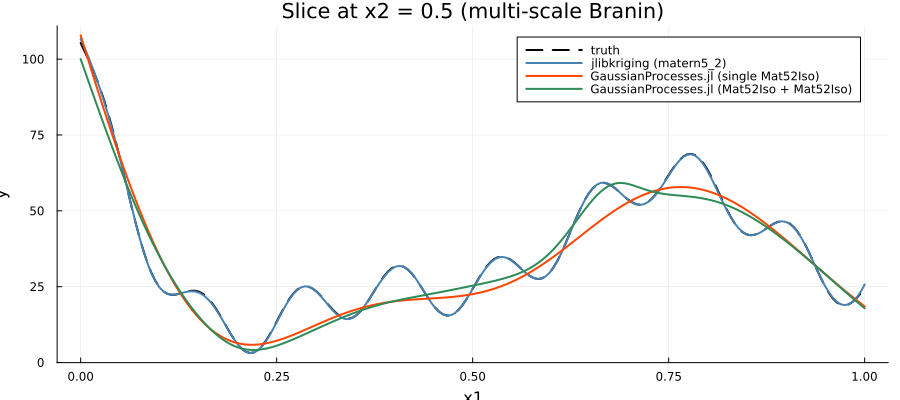

In [8]:
function plot_slices_multiscale()
    xs = range(0, 1, length=200)
    Xs1 = hcat(collect(xs), fill(0.5, 200))

    truth = branin_multiscale(Xs1)
    lk    = jlibkriging.predict(k2, Xs1; return_stdev=false, return_cov=false).mean
    single = predict_y(gp2_single, permutedims(Xs1))[1]
    comp   = predict_y(gp2_composite, permutedims(Xs1))[1]

    plot(xs, truth, lc=:black, lw=2, ls=:dash, label="truth",
         xlabel="x1", ylabel="y", title="Slice at x2 = 0.5 (multi-scale Branin)",
         legend=:topright, size=(900,400))
    plot!(xs, lk, lc=:steelblue, lw=2, label="jlibkriging (matern5_2)")
    plot!(xs, single, lc=:orangered, lw=2, label="GaussianProcesses.jl (single Mat52Iso)")
    plot!(xs, comp, lc=:seagreen, lw=2, label="GaussianProcesses.jl (Mat52Iso + Mat52Iso)")
end

plot_slices_multiscale()


## 5. Argument correspondence

| Concept                          | `jlibkriging` (`Kriging`)                              | `GaussianProcesses.jl` (`GP`)                                     |
|:----------------------------------|:--------------------------------------------------------|:--------------------------------------------------------------------|
| Design matrix layout             | `X`: `n × d` (rows = observations)                       | `X`: `d × n` (columns = observations) — transposed convention       |
| Kernel family                     | string: `"gauss"`, `"exp"`, `"matern3_2"`, `"matern5_2"` | composable objects: `SEIso`, `Mat32Iso`, `Mat52Iso`, `+`, `*`, ...   |
| Kernel hyperparameters            | linear-scale range/variance (internally optimized)       | `log`-scale (`ℓ`, `σ2`) fields on the kernel object                  |
| Trend / mean                     | `regmodel = "constant"/"linear"/"interactive"/"quadratic"` | `MeanZero()`, `MeanConst()`, `MeanLin()`, composable via `+`, `*`   |
| Fitting criterion                 | `objective = "LL"` (or `"LMP"`, `"LOO"`)                  | `optimize!(gp)` maximizes the exact marginal log-likelihood          |
| Optimizer                        | `optim = "BFGS"` / `"BFGS10"` (10 random restarts)        | `optimize!(gp)` — single gradient-based run (`Optim.jl`, no restart by default) |
| Prediction                        | `predict(k, Xnew; return_stdev, return_cov)`              | `predict_y(gp, Xnew)` → `(mean, variance)`                           |
| Observation noise                 | `NoiseKriging`, or `Kriging(..., noise="nugget")`         | `logNoise` argument to `GP(...)`                                    |
| Sampling from the posterior       | `simulate(k, nsim, seed, Xnew)`                           | `rand(gp, Xnew, nsim)`                                               |
